In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/ground_truth_coordinates.csv
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_04498.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_16279.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_11219.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_00610.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_12470.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_13700.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_10731.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_06407.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images/IMG_03973.jpg
/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/i

Original shape: (19002, 3)
    image_id   latitude   longitude
0  IMG_00001  50.381574   26.061851
1  IMG_00002  34.529443 -114.693194
2  IMG_00003 -25.080840  136.646181
3  IMG_00004  37.638610  -10.262691
4  IMG_00005 -33.966293   17.305832
Removed exact duplicates: 0
Rows with invalid coords /(0,0): 0


Validating images: 100%|██████████| 19002/19002 [01:23<00:00, 226.27it/s]


Valid images: 19002
Failed images: 0
Final dataframe shape: (19002, 3)


Checking EXIF GPS: 100%|██████████| 19002/19002 [00:24<00:00, 772.13it/s]


Images with EXIF GPS: 0
EXIF GPS matches CSV: 0


Computing pHash: 100%|██████████| 19002/19002 [02:11<00:00, 144.10it/s]


pHash rows: 0
Near duplicate pairs: 0


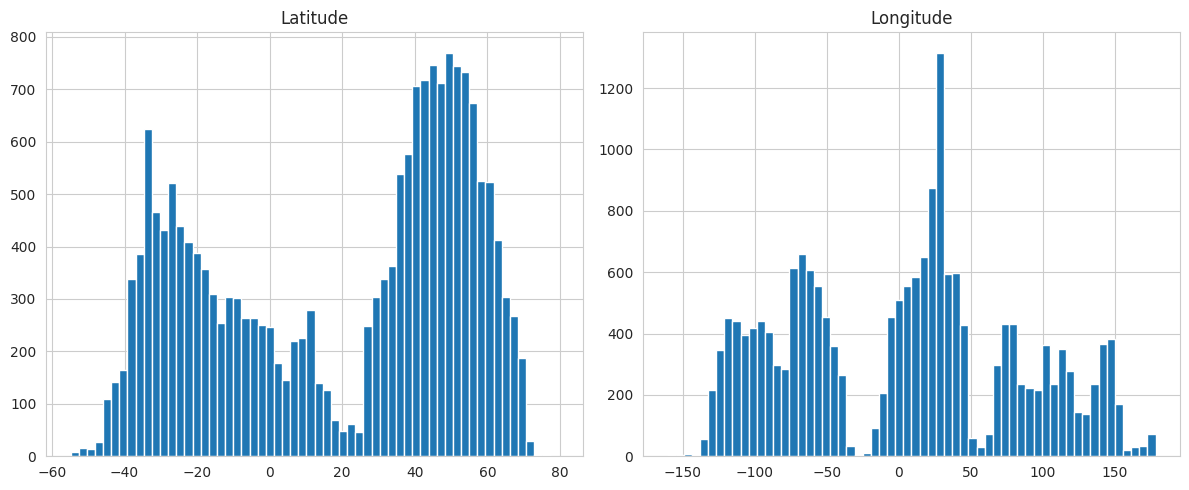

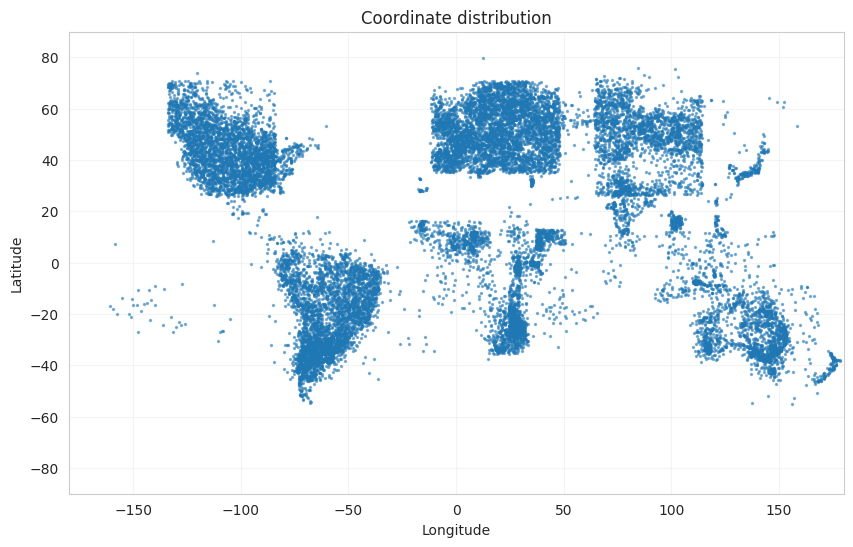

Saved: /kaggle/working/cleaned_dataset.csv
    image_id   latitude   longitude
0  IMG_00001  50.381574   26.061851
1  IMG_00002  34.529443 -114.693194
2  IMG_00003 -25.080840  136.646181
3  IMG_00004  37.638610  -10.262691
4  IMG_00005 -33.966293   17.305832


In [2]:
#data cleaning 
import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import imagehash
from tqdm import tqdm

sns.set_style("whitegrid")

TRAIN_CSV = "/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/ground_truth_coordinates.csv"
TRAIN_IMG_DIR = "/kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images"

def resolve_image_path(img_name):
    img_name = str(img_name).strip()
    if not img_name:
        return None

    candidates = [
        os.path.join(TRAIN_IMG_DIR, img_name),
        os.path.join(TRAIN_IMG_DIR, img_name + ".jpg"),
        os.path.join(TRAIN_IMG_DIR, img_name + ".jpeg"),
        os.path.join(TRAIN_IMG_DIR, img_name + ".png"),
        os.path.join(TRAIN_IMG_DIR, img_name + ".webp"),
    ]

    for p in candidates:
        if os.path.exists(p):
            return p
    return None

df = pd.read_csv(TRAIN_CSV)
df.columns = [str(c).strip().lower() for c in df.columns]

print("Original shape:", df.shape)
print(df.head())

# required columns
required = ["image_id", "latitude", "longitude"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df[required].copy()
df["image_id"] = df["image_id"].astype(str).str.strip()
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# exact dupes
before = len(df)
df = df.drop_duplicates()
print(f"Removed exact duplicates: {before - len(df)}")

# invalid coords
bad = (
    df["latitude"].isna()
    | df["longitude"].isna()
    | (df["latitude"] < -90)
    | (df["latitude"] > 90)
    | (df["longitude"] < -180)
    | (df["longitude"] > 180)
    | ((df["latitude"] == 0) & (df["longitude"] == 0))
)
print(f"Rows with invalid coords /(0,0): {bad.sum()}")
df = df[~bad].reset_index(drop=True)

# image validation
valid_idx = []
failed = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Validating images"):
    p = resolve_image_path(row["image_id"])
    if p is None:
        failed.append({"row": idx, "image_id": row["image_id"], "reason": "missing_file"})
        continue
    try:
        with Image.open(p) as img:
            img.verify()
        valid_idx.append(idx)
    except Exception as e:
        failed.append({"row": idx, "image_id": row["image_id"], "reason": f"cannot_open:{type(e).__name__}"})

print(f"Valid images: {len(valid_idx)}")
print(f"Failed images: {len(failed)}")
if failed:
    print(pd.DataFrame(failed[:10]))

df = df.loc[valid_idx].reset_index(drop=True)
print("Final dataframe shape:", df.shape)

# EXIF GPS audit
exif_hits = []
exif_count = 0

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Checking EXIF GPS"):
    p = resolve_image_path(row["image_id"])
    if p is None:
        continue
    try:
        with Image.open(p) as img:
            exif = img.getexif()
            gps = exif.get(34853)
            if gps is None:
                continue

            exif_count += 1

            lat_ref = gps.get(1)
            lat_val = gps.get(2)
            lon_ref = gps.get(3)
            lon_val = gps.get(4)
            if lat_val is None or lon_val is None:
                continue

            def dms_to_decimal(v):
                if isinstance(v, (tuple, list)) and len(v) == 3:
                    deg, minute, sec = v
                    return float(deg) + float(minute)/60 + float(sec)/3600
                return float(v)

            lat = dms_to_decimal(lat_val)
            lon = dms_to_decimal(lon_val)
            if str(lat_ref).upper() == "S":
                lat *= -1
            if str(lon_ref).upper() == "W":
                lon *= -1

            if abs(lat - float(row["latitude"])) < 1e-6 and abs(lon - float(row["longitude"])) < 1e-6:
                exif_hits.append({
                    "image_id": row["image_id"],
                    "csv_lat": float(row["latitude"]),
                    "csv_lon": float(row["longitude"]),
                    "exif_lat": lat,
                    "exif_lon": lon
                })
    except Exception:
        pass

print(f"Images with EXIF GPS: {exif_count}")
print(f"EXIF GPS matches CSV: {len(exif_hits)}")

# pHash duplicates
hash_rows = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Computing pHash"):
    p = resolve_image_path(row["image_id"])
    if p is None:
        continue
    try:
        with Image.open(p).convert("RGB") as img:
            h = imagehash.phash(img)
            hash_rows.append({"row_index": idx, "image_id": row["image_id"], "phash": int(h)})
    except Exception:
        pass

hash_df = pd.DataFrame(hash_rows)
print("pHash rows:", len(hash_df))

buckets = defaultdict(list)
for _, r in hash_df.iterrows():
    buckets[r["phash"] >> 52].append(r)

near_dupes = []
seen = set()

for rows in buckets.values():
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            a = rows[i]
            b = rows[j]
            d = bin(a["phash"] ^ b["phash"]).count("1")
            if d <= 5:
                key = tuple(sorted([a["row_index"], b["row_index"]]))
                if key not in seen:
                    seen.add(key)
                    near_dupes.append({
                        "left_index": a["row_index"],
                        "right_index": b["row_index"],
                        "left_image": a["image_id"],
                        "right_image": b["image_id"],
                        "hamming": d
                    })

print(f"Near duplicate pairs: {len(near_dupes)}")
if near_dupes:
    print(pd.DataFrame(near_dupes[:20]))

# distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df["latitude"], bins=60)
plt.title("Latitude")
plt.subplot(1, 2, 2)
plt.hist(df["longitude"], bins=60)
plt.title("Longitude")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df["longitude"], df["latitude"], s=2, alpha=0.5)
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.title("Coordinate distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.show()

out = "/kaggle/working/cleaned_dataset.csv"
df.to_csv(out, index=False)
print("Saved:", out)
print(df.head())

In [3]:
!pip install transformers scikit-learn tqdm -q

In [4]:
%%writefile 0_save_clip_locally.py
"""
Run once. Downloads CLIP (ViT-L/14) and saves it to a local folder,
so inference scripts can load it from disk with zero network access.
"""

from transformers import CLIPModel, CLIPProcessor

MODEL_NAME = "openai/clip-vit-large-patch14"
SAVE_DIR = "/kaggle/working/clip_local"

print(f"Downloading {MODEL_NAME}...")
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

print(f"Saved locally to {SAVE_DIR}")

Writing 0_save_clip_locally.py


In [5]:
!python 0_save_clip_locally.py

config.json: 4.52kB [00:00, 14.6MB/s]
model.safetensors: 100%|████████████████████| 1.71G/1.71G [00:08<00:00, 192MB/s]
Loading weights: 100%|█| 590/590 [00:00<00:00, 1415.67it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
preprocessor_config.json: 100%|████████████████| 316/316 [00:00<00:00, 1.71MB/s]
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
toke

In [6]:
%%writefile 1_extract_embeddings.py
"""
Step 1: Extract frozen CLIP image embeddings for your whole dataset.
Runs once. GPU-heavy step.
"""

import argparse
import os
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--csv", required=True)
    p.add_argument("--image_dir", required=True)
    p.add_argument("--out_dir", default="embeddings")
    p.add_argument("--model_name", default="openai/clip-vit-base-patch32")
    p.add_argument("--batch_size", type=int, default=64)
    p.add_argument("--id_col", default="image_id")
    p.add_argument("--lat_col", default="latitude")
    p.add_argument("--lon_col", default="longitude")
    p.add_argument("--image_ext", default=".jpg")
    return p.parse_args()


def resolve_image_path(image_dir, image_id, default_ext):
    known_exts = (".jpg", ".jpeg", ".png", ".webp")
    if str(image_id).lower().endswith(known_exts):
        return os.path.join(image_dir, str(image_id))
    return os.path.join(image_dir, f"{image_id}{default_ext}")


def extract_feature_tensor(output):
    if torch.is_tensor(output):
        return output
    if hasattr(output, "image_embeds"):
        return output.image_embeds
    if hasattr(output, "pooler_output"):
        return output.pooler_output
    raise TypeError(f"Unexpected output type from get_image_features: {type(output)}")


def main():
    args = parse_args()
    os.makedirs(args.out_dir, exist_ok=True)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    df = pd.read_csv(args.csv)
    assert {args.id_col, args.lat_col, args.lon_col}.issubset(df.columns), \
        f"CSV must have {args.id_col}, {args.lat_col}, {args.lon_col} columns. Found: {list(df.columns)}"
    print(f"Loaded {len(df)} rows from {args.csv}")

    print(f"Loading frozen encoder: {args.model_name}")
    model = CLIPModel.from_pretrained(args.model_name).to(device)
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    processor = CLIPProcessor.from_pretrained(args.model_name)

    all_embeddings = []
    all_coords = []
    all_paths = []
    failed = []

    batch_imgs, batch_coords, batch_paths = [], [], []

    def flush_batch():
        if not batch_imgs:
            return
        inputs = processor(images=batch_imgs, return_tensors="pt").to(device)
        with torch.no_grad():
            raw_output = model.get_image_features(**inputs)
            feats = extract_feature_tensor(raw_output)
            feats = feats / feats.norm(dim=-1, keepdim=True)
        all_embeddings.append(feats.cpu().numpy())
        all_coords.extend(batch_coords)
        all_paths.extend(batch_paths)

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting embeddings"):
        img_path = resolve_image_path(args.image_dir, row[args.id_col], args.image_ext)
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            failed.append((img_path, str(e)))
            continue

        batch_imgs.append(img)
        batch_coords.append((row[args.lat_col], row[args.lon_col]))
        batch_paths.append(img_path)

        if len(batch_imgs) >= args.batch_size:
            flush_batch()
            batch_imgs, batch_coords, batch_paths = [], [], []

    flush_batch()

    embeddings = np.concatenate(all_embeddings, axis=0)
    coords = np.array(all_coords, dtype=np.float64)

    np.save(os.path.join(args.out_dir, "embeddings.npy"), embeddings)
    np.save(os.path.join(args.out_dir, "coords.npy"), coords)
    with open(os.path.join(args.out_dir, "paths.txt"), "w") as f:
        f.write("\n".join(all_paths))

    print(f"\nDone. Saved {embeddings.shape[0]} embeddings of dim {embeddings.shape[1]}")
    if failed:
        print(f"\n{len(failed)} images failed to load (skipped). First few:")
        for p, e in failed[:5]:
            print(f"  {p}: {e}")


if __name__ == "__main__":
    main()

Writing 1_extract_embeddings.py


In [7]:
!python 1_extract_embeddings.py \
    --csv /kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/ground_truth_coordinates.csv \
    --image_dir /kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/images \
    --model_name openai/clip-vit-large-patch14 \
    --out_dir /kaggle/working/embeddings

Using device: cuda
Loaded 19002 rows from /kaggle/input/datasets/yadhunandandme26b146/geoguessssr/noised_dataset/ground_truth_coordinates.csv
Loading frozen encoder: openai/clip-vit-large-patch14
Loading weights: 100%|█| 590/590 [00:00<00:00, 1699.52it/s, Materializing param=
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Extracti